<a href="https://colab.research.google.com/github/kanahash/Graduate_School_research_code/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.fftpack as sf
from IPython import display
from IPython.display import HTML
import math as mt
import matplotlib.animation as animation
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
shot_no=42
dir='/content/drive/MyDrive/hw_simuration/MHW_data/data{}/'.format(shot_no)

In [ ]:
phi_evo=np.load(dir+'phi_evo.npy')
N_evo=np.load(dir+'N_evo.npy')
t_arr=np.load(dir+'t_arr.npy')
x_arr=np.load(dir+'x_arr.npy')
y_arr=np.load(dir+'y_arr.npy')

[nx,ny,lx,ly,nt,dt,kap,alph,mu,nu]=np.load(dir+'params.npy')

In [ ]:
x_arr.shape

(256,)

In [ ]:
phi_evo = np.transpose(phi_evo, (0, 2, 1))  # [t, x, y] の形状に変換
N_evo = np.transpose(N_evo, (0, 2, 1))  # [t, x, y] の形状に変換

In [ ]:
phi_evo.shape

(2000, 256, 256)

In [ ]:
N_t=t_arr.size
N_x=x_arr.size
N_y=y_arr.size

In [ ]:
lx.shape

()

In [ ]:
ly.shape

()

In [ ]:
t_max = 4000
# nx_max = 256
# ny_max = 256

In [ ]:
# tの範囲をphi_evoの形状に合わせる
t = np.linspace(0, t_max, 2000)  # 2000個の要素

In [ ]:
lx = np.linspace(0, 2 * np.pi / 0.15, 256)  # 0から2π/0.15までの範囲
ly = np.linspace(0, 32 * np.pi, 256)  # 0から32πまでの範囲

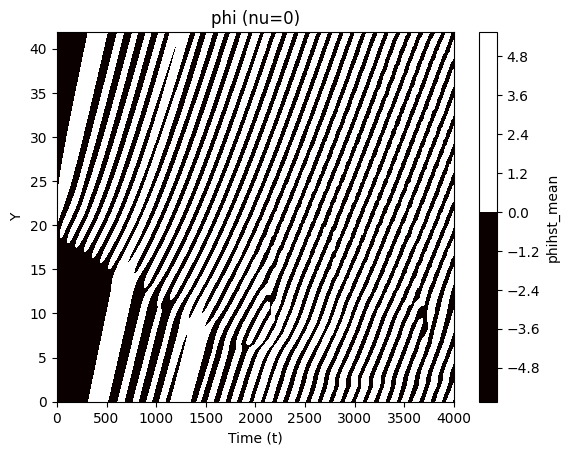

In [ ]:
# t = np.arange(t_max)

X,Y = np.meshgrid( t, lx)

contour = plt.contourf(X,Y,phi_evo[:,0,:].T,100,cmap = 'hot')

contour.set_clim(-0.03, 0.03)

plt.title("phi (nu=0)")
plt.xlabel('Time (t)')
plt.ylabel('Y')
plt.colorbar(contour, label='phihst_mean')

# グラフを表示
plt.show()

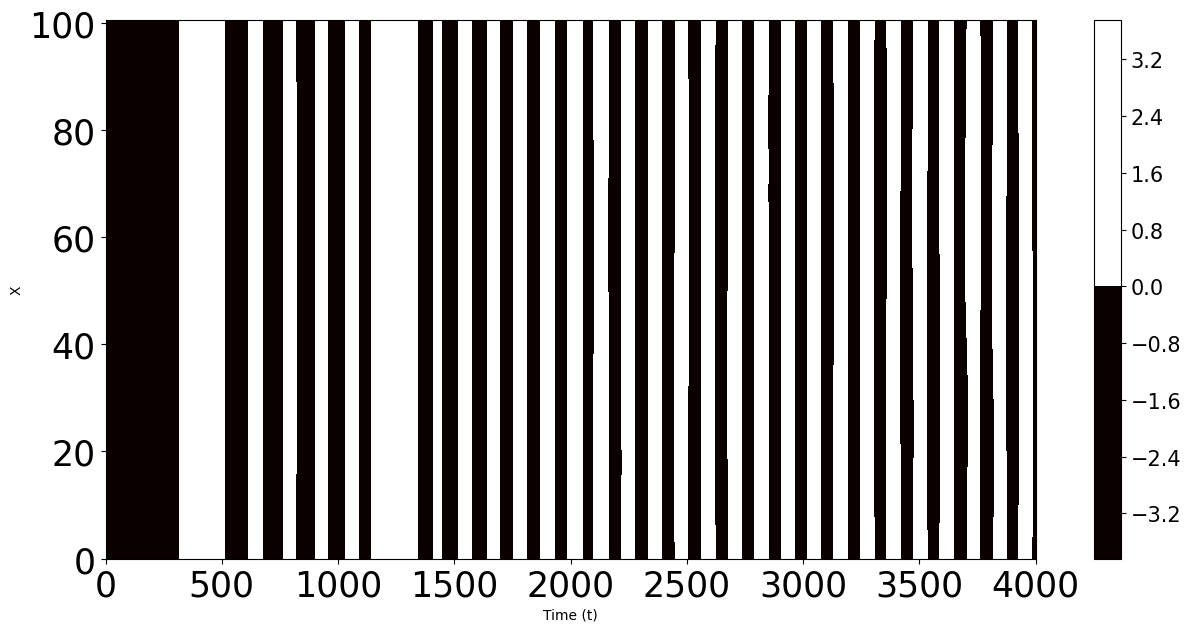

In [ ]:
plt.figure(figsize=(15, 7))

X,Y = np.meshgrid( t, ly)

contour = plt.contourf(X,Y,phi_evo[:,:,0].T,100,cmap = 'hot')

contour.set_clim(-0.03, 0.03)

# plt.title("phi (nu=0)")
plt.xlabel('Time (t)')
plt.ylabel('X')
plt.rcParams["font.size"] = 15

plt.tick_params(axis='both', which='major', labelsize=25)

plt.colorbar(contour)
# グラフを表示
plt.show()

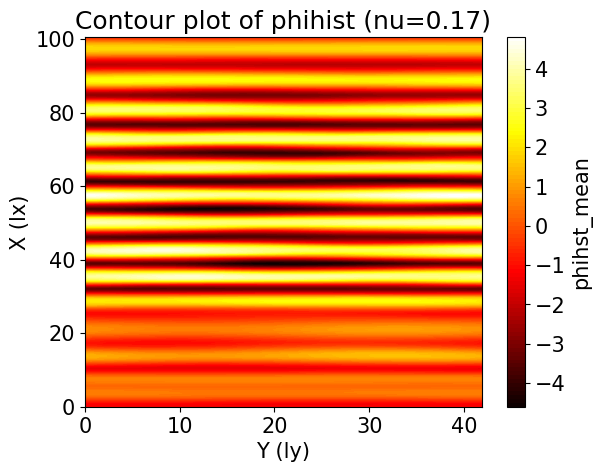

In [ ]:
X,Y = np.meshgrid( lx, ly)

contour = plt.contourf(X,Y,phi_evo[1499,:,:].T,100,cmap = 'hot')

#contour.set_clim(-0.03, 0.03)

plt.title("Contour plot of phihist (nu=0.17)")
plt.ylabel('X (lx)')
plt.xlabel('Y (ly)')
plt.colorbar(contour, label='phihst_mean')

# グラフを表示
plt.show()

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.colors import Normalize

from IPython.display import Image, display

X, Y = np.meshgrid(lx, ly)

fig, ax = plt.subplots()
ax.set_title("Contour plot of phihist (nu=0)")
ax.set_ylabel("X (lx)")
ax.set_xlabel("Y (ly)")

# 白黒回避：全時間のデータから色スケール決定（外れ値に強い）
vmin, vmax = np.nanpercentile(phi_evo, [1, 99])
norm = Normalize(vmin=vmin, vmax=vmax)

img = ax.imshow(
    phi_evo[0, :, :].T,
    cmap="hot",
    norm=norm,
    origin="lower",
    aspect="auto",
    extent=[ly.min(), ly.max(), lx.min(), lx.max()],
)

cbar = fig.colorbar(img)
cbar.set_label("phihst_mean")

time_text = ax.text(0.98, 0.98, "", transform=ax.transAxes, ha="right", va="top")

def update(frame):
    img.set_data(phi_evo[frame, :, :].T)
    time_text.set_text(f"t idx = {frame}")
    return img, time_text

ani = FuncAnimation(fig, update, frames=phi_evo.shape[0], interval=50, blit=True)

out_gif = "phi_evo_contour.gif"
ani.save(out_gif, writer=PillowWriter(fps=20))

plt.close(fig)

print("saved:", os.path.abspath(out_gif))
print("exists:", os.path.exists(out_gif))
print("cwd:", os.getcwd())

display(Image(filename=out_gif))


saved: /content/phi_evo_contour.gif
exists: True
cwd: /content
Buffered data was truncated after reaching the output size limit.

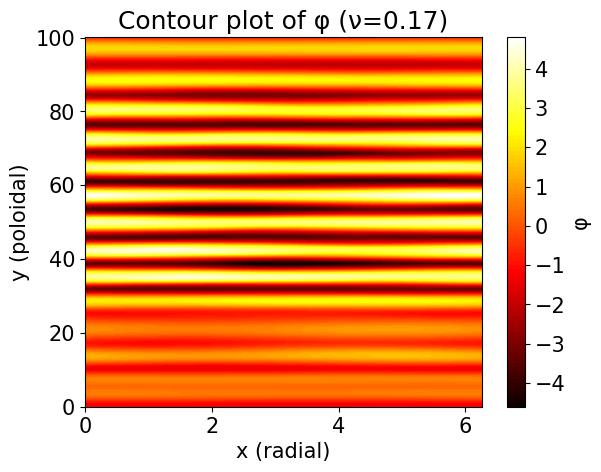

In [ ]:
X, Y = np.meshgrid(x_arr, y_arr)

contour = plt.contourf(
    X, Y,
    phi_evo[1499,:,:].T,
    100,
    cmap='hot'
)

plt.xlabel('x (radial)')
plt.ylabel('y (poloidal)')
plt.title('Contour plot of φ (ν=0.17)')
plt.colorbar(contour, label='φ')

plt.show()

In [ ]:
# # lx, lyがもともと(256, 0)の形なので、lxとlyの正しい範囲を設定
delta_x = 2 * np.pi / 0.15
delta_y = 32 * np.pi

lx = np.linspace(-delta_x, delta_x, 256)  # lxの範囲を256に設定
ly = np.linspace(-delta_y, delta_y, 256)  # lyの範囲を256に設定

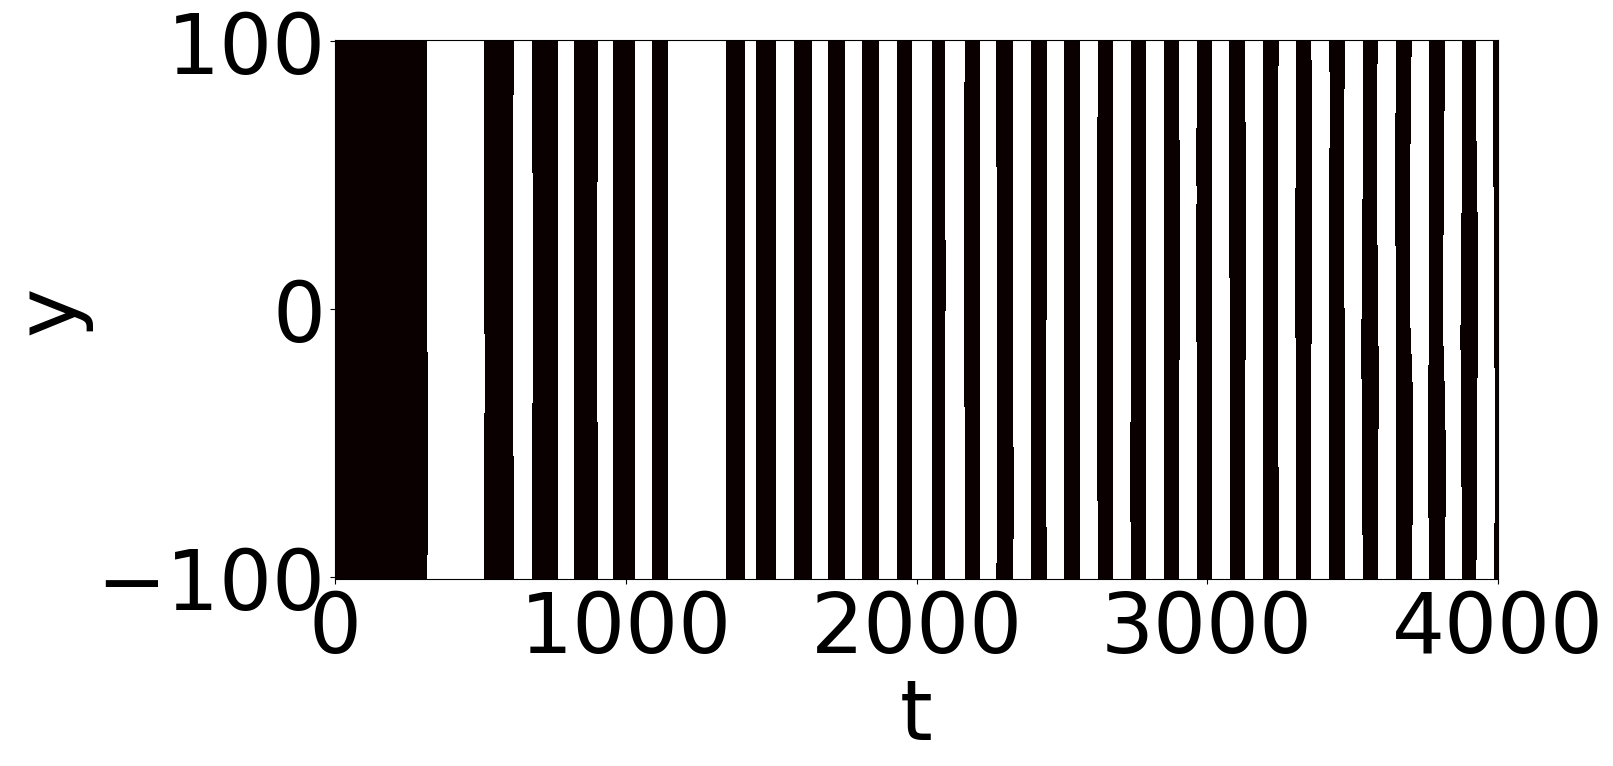

In [ ]:
plt.figure(figsize=(15, 7))

X,Y = np.meshgrid( t, ly)

contour = plt.contourf(X,Y,phi_evo[:,:,0].T,100,cmap = 'hot')

contour.set_clim(-0.03, 0.03)

# plt.title("phi (nu=0)")
plt.xlabel('t',fontsize=60)
plt.ylabel('y',fontsize=60)
plt.rcParams["font.size"] = 15

plt.tick_params(axis='both', which='major', labelsize=60)

#plt.colorbar(contour)
# グラフを表示
plt.show()

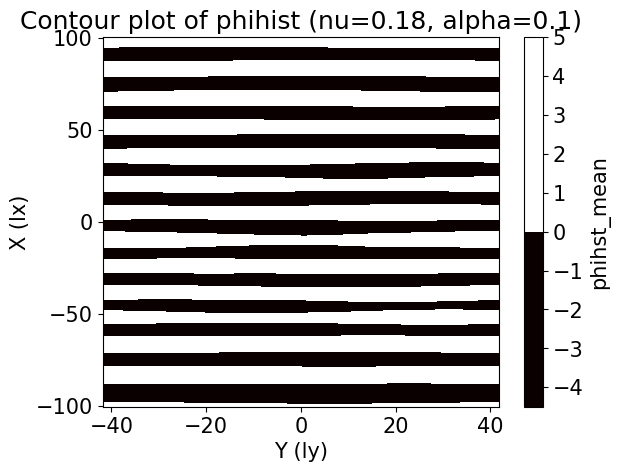

In [ ]:
X,Y = np.meshgrid( lx, ly)

contour = plt.contourf(X,Y,phi_evo[1800,:,:].T,100,cmap = 'hot')

contour.set_clim(-0.03, 0.03)

plt.title("Contour plot of phihist (nu=0.18, alpha=0.1)")
plt.ylabel('X (lx)')
plt.xlabel('Y (ly)')
plt.colorbar(contour, label='phihst_mean')

# グラフを表示
plt.show()

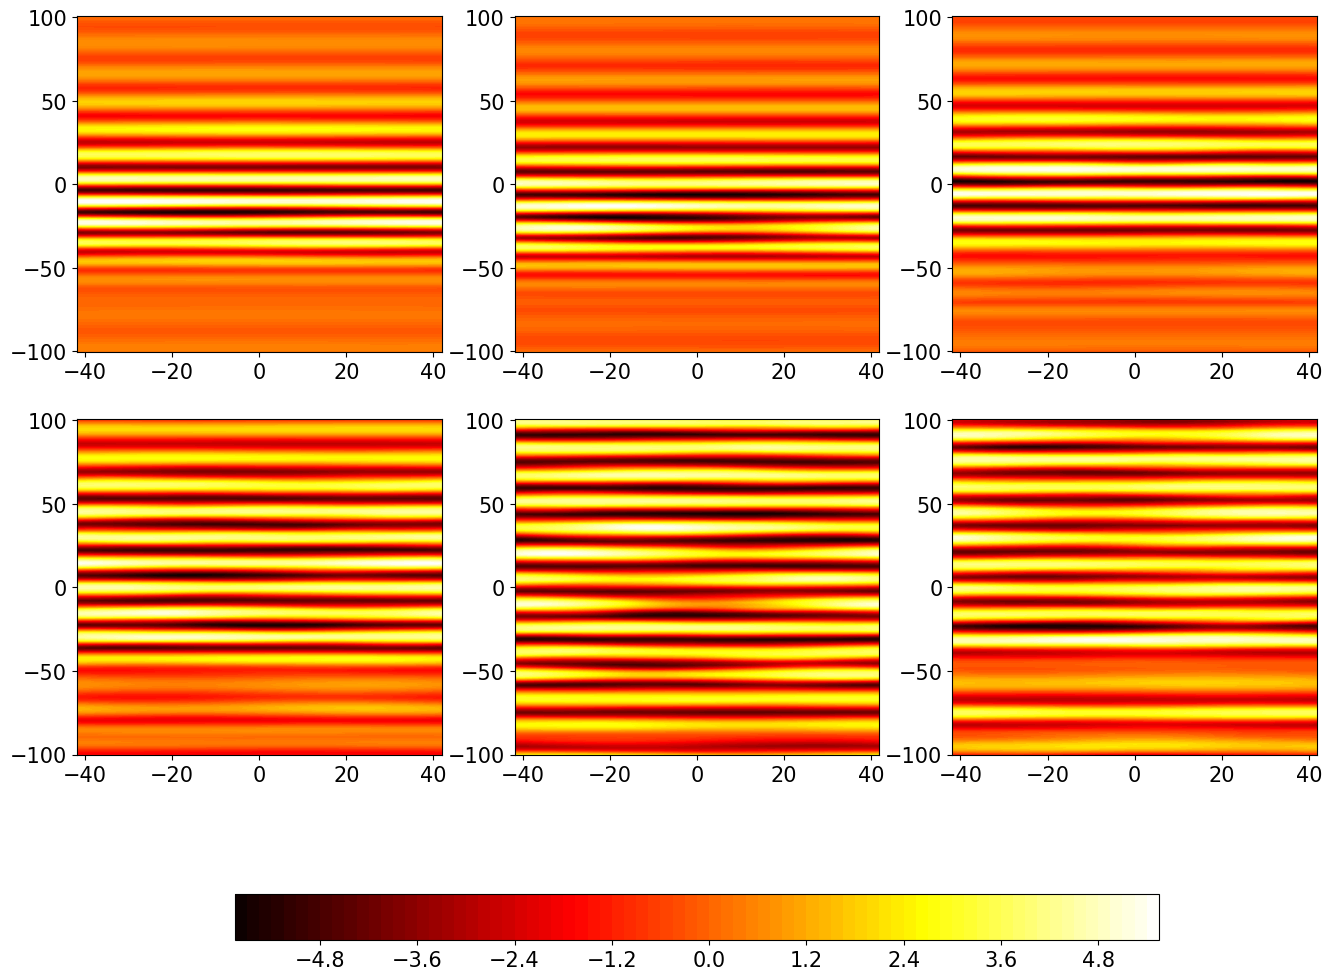

In [ ]:
# figureとaxesを作成
fig, axes = plt.subplots(2, 3, figsize=(16, 12))

# 各サブプロットに異なる時刻の等高線を描画
time_indices = [900,1000, 1200, 1500, 1800, 1999]  # 使用するphi_evoのインデックス
for i in range(2):
    for j in range(3):
        idx = i * 3 + j  # time_indicesのインデックスを計算
        contour = axes[i][j].contourf(X, Y, phi_evo[time_indices[idx], :, :].T, 100, cmap='hot')
        axes[i][j].set_xlim(-delta_x, delta_x)
        axes[i][j].set_ylim(-delta_y, delta_y)

# カラーバーを追加
fig.colorbar(contour, ax=axes.ravel().tolist(), orientation='horizontal', fraction=0.05)

plt.show()

In [ ]:
N_evo.shape

(2000, 256, 256)

In [ ]:
# def cal_x_derivative(phi,x_arr):
#     dx_phi=np.zeros_like(phi)
#     dx=x_arr[2]-x_arr[0]
#     N_x=x_arr.size
#     dx_phi[:,1:N_x-2,:]=(phi[:,2:N_x-1,:]-phi[:,0:N_x-3,:])/dx
#     dx_phi[:,0,:]=(phi[:,1,:]-phi[:,N_x-1,:])/dx
#     dx_phi[:,N_x-1,:]=(phi[:,0,:]-phi[:,N_x-2,:])/dx
#     dx_phi[:,N_x-2,:]=(phi[:,N_x-1,:]-phi[:,N_x-3,:])/dx
#     return dx_phi

In [ ]:
# def cal_y_derivative(phi,y_arr):
#     dy_phi=np.zeros_like(phi)
#     dy=y_arr[2]-y_arr[0]
#     N_y=y_arr.size
#     dy_phi[:,:,1:N_y-2]=(phi[:,:,2:N_y-1]-phi[:,:,0:N_y-3])/dy
#     dy_phi[:,:,0]=(phi[:,:,1]-phi[:,:,N_y-1])/dy
#     dy_phi[:,:,N_y-1]=(phi[:,:,0]-phi[:,:,N_y-2])/dy
#     dy_phi[:,:,N_y-2]=(phi[:,:,N_y-1]-phi[:,:,N_y-3])/dy
#     return dy_phi

In [ ]:
# cal_x_derivative 関数の修正版
def cal_x_derivative(phi, x_arr):
    # dx は x_arr[i+1] - x_arr[i-1] の差分、つまり 2 * Delta_x に相当
    # x_arrが間引かれていても、この差は一定であると仮定
    dx = x_arr[2] - x_arr[0]

    # phi_{i+1} (x軸方向に-1シフト)
    phi_plus_1 = np.roll(phi, shift=-1, axis=1)
    # phi_{i-1} (x軸方向に+1シフト)
    phi_minus_1 = np.roll(phi, shift=1, axis=1)

    # 中央差分: (phi_{i+1} - phi_{i-1}) / (2 * Delta_x)
    dx_phi = (phi_plus_1 - phi_minus_1) / dx

    return dx_phi

# cal_y_derivative も同様に修正することでより堅牢になります（こちらは任意）
def cal_y_derivative(phi, y_arr):
    dy = y_arr[2] - y_arr[0]

    # y軸 (axis=2)
    phi_plus_1 = np.roll(phi, shift=-1, axis=2)
    phi_minus_1 = np.roll(phi, shift=1, axis=2)

    dy_phi = (phi_plus_1 - phi_minus_1) / dy

    return dy_phi

In [ ]:
def cal_ZF_comp(phi):
    phi_ZF=np.mean(phi,axis=2)
    dum1, dum2, dum3 =phi.shape
    expanded_data = np.expand_dims(phi_ZF, axis=2)
    result = np.repeat(expanded_data, dum3, axis=2)
    return result
    #return phi_ZF

In [ ]:
def cal_ST_comp(phi):
    phi_ST=np.mean(phi,axis=1)
    dum1, dum2, dum3 =phi.shape
    expanded_data = np.expand_dims(phi_ST, axis=1)
    result = np.repeat(expanded_data, dum2, axis=1)
    return result

In [ ]:
# --- ここでクラッシュする前に挿入 ---

# 間引き処理：3個飛ばし (インデックス0, 3, 6, ... の要素を取得)
# スライシング [開始:終了:ステップ] を利用
step = 5

# 間引き後のデータ
phi_evo_subsampled = phi_evo[::step]
N_evo_subsampled = N_evo[::step]

# もし計算に必要な他の配列（時間軸など）があれば、それらも間引く
# t_evo_subsampled = t_evo[::step]

# 間引き後のデータ（例：phi_turb_subsampled）を使って、次の処理を実行する

# --- ここからクラッシュしていた処理を再開 ---

In [ ]:
phi_ZF=cal_ZF_comp(phi_evo_subsampled)
phi_ST=cal_ST_comp(phi_evo_subsampled)
phi_turb=phi_evo_subsampled-phi_ZF-phi_ST

N_ZF=cal_ZF_comp(N_evo_subsampled)
N_ST=cal_ST_comp(N_evo_subsampled)
N_turb=N_evo_subsampled-N_ZF-N_ST

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12288 (\N{IDEOGRAPHIC SPACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


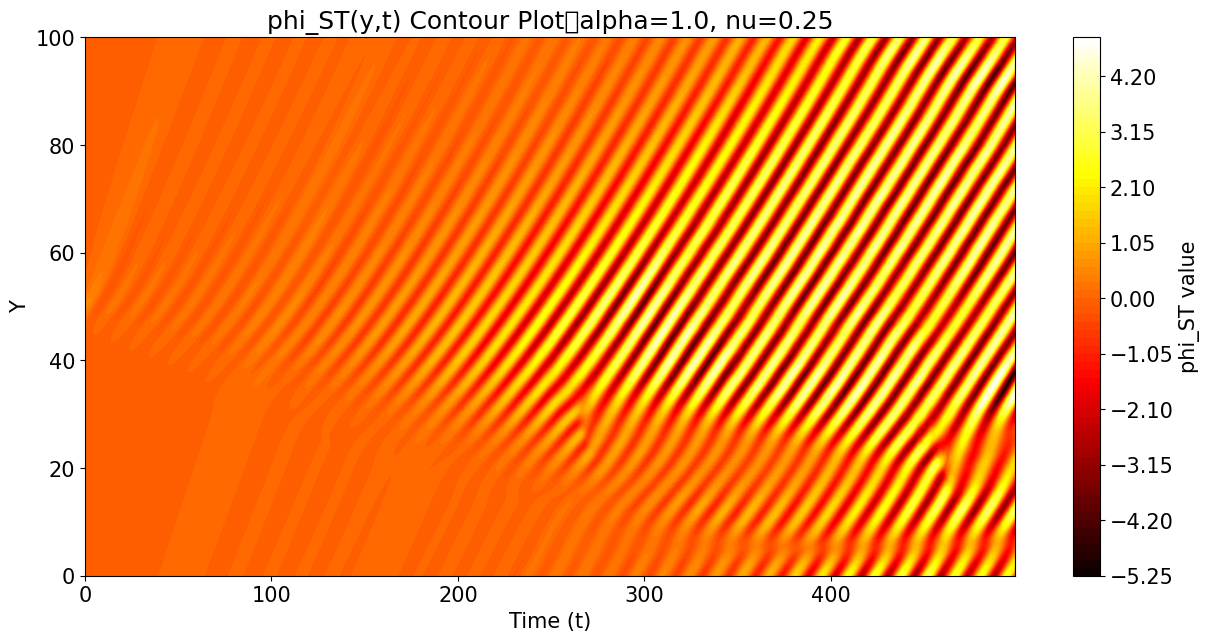

In [ ]:
plt.figure(figsize=(15, 7))

# phi_evo_subsampled の時間軸に対応する配列
t_arr_subsampled = t_arr[::step]

X, Y = np.meshgrid(t_arr_subsampled, y_arr)

contour = plt.contourf(X, Y, phi_ST[:, 0, :].T, 100, cmap='hot')
plt.title('phi_ST(y,t) Contour Plot　alpha=1.0, nu=0.25')
plt.xlabel('Time (t)', fontsize=15)
plt.ylabel('Y', fontsize=15)
plt.colorbar(contour, label='phi_ST value')
plt.show()

In [ ]:
phi_turb[:, ::2, :].shape

(400, 128, 256)

In [ ]:
# 空間方向のスキップ数 (4分の1に削減)
spatial_step = 4

# phi_ZFを空間方向（2番目と3番目のインデックス）に間引く
# phi_ZF[:, ::4, ::4] の形状は (1200, 64, 64) になります (256/4 = 64)
phi_ZF_subsampled = phi_ZF[:, ::spatial_step, ::spatial_step]

# x_arr も空間方向の間引きに合わせて間引く
# cal_x_derivativeの計算が正しく行われるように、x_arrもphi_ZFの間引きと対応させる必要があります
x_arr_subsampled = x_arr[::spatial_step]

# 間引いたデータで計算を実行
V_y_ZF = cal_x_derivative(phi_ZF_subsampled, x_arr_subsampled)

# phi_ZF は (1200, 256, 256)
# x_arr は (256,)
# V_y_ZF の形状は (1200, 64, 64) になり、計算負荷が大幅に軽減されます。

In [ ]:
V_y_ZF=cal_x_derivative(phi_ZF_subsampled,x_arr)

In [ ]:
V_x_ZF=cal_x_derivative(phi_ZF_subsampled,x_arr)

In [ ]:
x_arr.shape

(256,)

In [ ]:
dx_phi_turb=cal_x_derivative(phi_turb[::3,::3,::3],x_arr[::3])

In [ ]:
dy_phi_turb=cal_y_derivative(phi_turb[::3,::3,::3],y_arr[::3])

In [ ]:
Gamma_x=-N_evo_subsampled[::3,::3,::3]*dy_phi_turb
Gama_x_ZF=cal_ZF_comp(Gamma_x)

In [ ]:
plt.subplots(figsize = (3, 5))
plt.contourf(x_arr[::3],t_arr[::15],Gama_x_ZF[:,:,1], 50, cmap='hot')
plt.colorbar(shrink=0.8, pad=0.1)
plt.subplots_adjust(right=1.2)
contour.set_clim(-0.000003, 0.000003)

plt.xlabel('x')
plt.ylabel('t')
plt.show()

In [ ]:
dum=N_turb[::3,::3,::3]**2+dx_phi_turb**2+dy_phi_turb**2
I_turb=np.mean(dum,axis=2)

In [ ]:
bt=256

In [ ]:
plt.plot(x_arr[::3],dx_phi_turb[bt,:,1]**2)

In [ ]:
print("Gamma_x の形状:", Gamma_x.shape)

In [ ]:
Gamma_x_y_avg = np.mean(Gamma_x, axis=1)

In [ ]:
plt.contourf(dx_phi_turb[:,1,:]**2)
plt.colorbar(shrink=0.8, pad=0.1)
plt.subplots_adjust(right=1.2)
contour.set_clim(-0.000003, 0.000003)

plt.xlabel('x')
plt.ylabel('t')
plt.show()

In [ ]:
# bt=1800
# plt.contourf(x_arr,y_arr,phi_ZF[bt,:,:].T)
# plt.show()
# plt.contourf(x_arr,y_arr,np.squeeze(phi_ST[bt,:,:].T))
# plt.show()
# plt.contourf(x_arr,y_arr,np.squeeze(phi_turb[bt,:,:].T))
# plt.show()

In [ ]:
# bt = 1800 # <-- エラーになる値
# phi_ZFの時間軸の最大インデックスは 1199 です。
bt = 1199

# --- プロットの実行 ---
# x_arr, y_arr は元のフルサイズ (256,) と仮定します。
# phi_ZF, phi_ST, phi_turb は時間軸が 1200 ステップの配列です。

plt.figure()
plt.contourf(x_arr, y_arr, phi_ZF[bt, :, :].T)
plt.title(f"phi_ZF at bt={bt}")
plt.show()

plt.figure()
plt.contourf(x_arr, y_arr, np.squeeze(phi_ST[bt, :, :].T))
plt.title(f"phi_ST at bt={bt}")
plt.show()

plt.figure()
plt.contourf(x_arr, y_arr, np.squeeze(phi_turb[bt, :, :].T))
plt.title(f"phi_turb at bt={bt}")
plt.show()

In [ ]:
def cal_x_derivative(phi,x_arr):
    dx_phi=np.zeros_like(phi)
    dx=x_arr[2]-x_arr[0]
    N_x=x_arr.size
    dx_phi[:,1:N_x-2,:]=(phi[:,2:N_x-1,:]-phi[:,0:N_x-3,:])/dx
    dx_phi[:,0,:]=(phi[:,1,:]-phi[:,N_x-1,:])/dx
    dx_phi[:,N_x-1,:]=(phi[:,0,:]-phi[:,N_x-2,:])/dx
    dx_phi[:,N_x-2,:]=(phi[:,N_x-1,:]-phi[:,N_x-3,:])/dx
    return dx_phi

In [ ]:
def cal_y_derivative(phi,y_arr):
    dy_phi=np.zeros_like(phi)
    dy=y_arr[2]-y_arr[0]
    N_y=y_arr.size
    dy_phi[:,:,1:N_y-2]=(phi[:,:,2:N_y-1]-phi[:,:,0:N_y-3])/dy
    dy_phi[:,:,0]=(phi[:,:,1]-phi[:,:,N_y-1])/dy
    dy_phi[:,:,N_y-1]=(phi[:,:,0]-phi[:,:,N_y-2])/dy
    dy_phi[:,:,N_y-2]=(phi[:,:,N_y-1]-phi[:,:,N_y-3])/dy
    return dy_phi

In [ ]:
def cal_energy(N,phi,x_arr,y_arr):
    phi_ZF=cal_ZF_comp(phi)
    N_ZF=cal_ZF_comp(N)
    phi_ST=cal_ST_comp(phi)
    N_ST=cal_ST_comp(N)

    phi_turb=phi-phi_ZF-phi_ST
    N_turb=N-N_ZF-N_ST

    dx_phi_ZF=cal_x_derivative(phi_ZF,x_arr)
    dx_phi_turb=cal_x_derivative(phi_turb,x_arr)
    dy_phi_turb=cal_y_derivative(phi_turb,y_arr)
    dy_phi_ST=cal_y_derivative(phi_ST,y_arr)

    E_turb=1/2*np.sum(np.sum(dx_phi_turb**2+dy_phi_turb**2+N_turb**2,axis=2),axis=1)
    E_ZF=1_2*np.sum(np.sum(dx_phi_ZF**2,axis=2),axis=1)
    E_ST=1_2*np.sum(np.sum(dy_phi_ST**2,axis=2),axis=1)
    return E_turb, E_ZF, E_ST

In [ ]:
V_y_ZF=cal_x_derivative(phi_ZF[::3,::3,::3],x_arr[::3])

In [ ]:
bt=200
plt.plot(x_arr[::3],V_y_ZF[bt,:,1],'b')

In [ ]:
#bt=1000
plt.contourf(x_arr,y_arr,np.squeeze(phi_turb[bt,:,:].T),100,cmap='hot')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar()

In [ ]:
dum=0
output_dir=dir+'/cont_phi_turb_Vy'

if dum==1:
    for bt in range(0,N_t,10):
        plt.subplots(figsize=(5, 3))
        cf=plt.contourf(x_arr,y_arr,np.squeeze(phi_turb[bt,:,:].T), levels=np.linspace(-7, 7, 100),cmap='hot')
        plt.plot(x_arr,V_y_ZF[bt,:,1]*2+20,'w')
        plt.xlabel('x')
        plt.ylabel('y')
        cbar = plt.colorbar(cf)
        cbar.set_ticks(np.linspace(-7, 7, 5))
        plt.title(f't= {t_arr[bt]}')
        if dum==1:
            filename = os.path.join(output_dir, f'cont_phi_Vy_{bt:03d}.png')
            plt.savefig(filename, bbox_inches='tight')
            plt.close()
        plt.show()

In [ ]:
plt.plot(x_arr,N_ZF[bt,:,1]*1.0-kap*x_arr+30.0)
plt.xlabel('x')
plt.ylabel('<N>')

In [ ]:
N_evo.shape

In [ ]:
phi_evo.shape

In [ ]:
E_turb,E_ZF,E_ST=cal_energy(N_evo_subsampled[::2,::2,::2],phi_evo_subsampled[::2,::2,::2],x_arr[::2],y_arr[::2])

In [ ]:
plt.semilogy(t_arr[::10],E_turb,'r',label='turb')
plt.semilogy(t_arr[::10],E_ZF,'b',label='ZF')
plt.semilogy(t_arr[::10],E_ST,'k',label='ST')
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
plt.xlabel('t')
plt.ylabel('Energy')
plt.show()

In [ ]:
# N_evo_subsampled は時間軸が 1200 ステップの配列 (N_evo[::5]に相当)

# N_evo_subsampled を時間軸でステップ 100 で間引く (1200 / 100 = 12 ステップ)
Gamma_x = -N_evo_subsampled[::3, ::3, ::3] * dy_phi_turb
Gama_x_ZF = cal_ZF_comp(Gamma_x)

In [ ]:
dx_phi_turb=cal_x_derivative(phi_turb[::2],x_arr[::2])
dy_phi_turb=cal_y_derivative(phi_turb[::2],y_arr[::2])
Gamma_x=-N_evo_subsampled[::2]*dy_phi_turb
Gama_x_ZF=cal_ZF_comp(Gamma_x)

In [ ]:
plt.subplots(figsize = (3, 5))
plt.contourf(x_arr,t_arr[::10],Gama_x_ZF[:,:,1], 50, cmap='hot')
plt.colorbar(shrink=0.8, pad=0.1)
plt.subplots_adjust(right=1.2)
plt.xlabel('x')
plt.ylabel('t')
plt.show()

In [ ]:
N_turb.shape

In [ ]:
dx_phi_turb.shape

In [ ]:
dy_phi_turb.shape

In [ ]:
E_turb_last_t = E_turb[599:999]

E_turb_mean = np.mean(E_turb_last_t)

In [ ]:
E_turb_mean

In [ ]:
E_ZF_last_t = E_ZF[599:999]

E_ZF_mean = np.mean(E_ZF_last_t)

In [ ]:
E_ZF_mean

In [ ]:
E_ST_last_t = E_ST[599:999]

E_ST_mean = np.mean(E_ST_last_t)

In [ ]:
E_ST_mean

In [ ]:
nu1 = [0, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.2, 0.21, 0.22,0.23, 0.24, 0.25, 0.26, 0.27, 0.28,0.29]

E_turb1 = [3625.265, 7582.445, 6792.131, 5102.548, 3741.816, 2524.78, 1953.1153,1610.7582, 1188.957, 0.706408,0.10341, 0.07955, 0.077395,0.07652, 0.07587, 0.07535, 0.0749, 0.07457, 0.07429]
E_ZF1 = [482341.39, 5562.757, 3012.9859, 1545.5553, 1139.442, 726.0297, 424.158693450116, 174.895054902459, 101.9696, 3.28907, 6.84397, 1.3139, 4.09845, 2.62724, 1.8287, 1.29645, 9.294598,6.7285, 4.91471]
E_ST1 = [1133.48696, 4933.627, 4733.946, 4106.5877,2611.1628, 2513.7015, 1605.79791482747, 2326.25982668884, 1668.35387079238, 12.0718, 0.4392, 0.03314, 0.01288, 0.01084, 0.01002, 0.00937, 0.00879,0.008274, 0.007808]

In [ ]:
plt.plot(nu1, E_turb1)
plt.xlabel('nu')
plt.ylabel('Energy_turb')
plt.show()

In [ ]:
plt.plot(nu1, E_ZF1)
plt.xlabel('nu')
plt.ylabel('Energy_ZF')
plt.show()

In [ ]:
plt.plot(nu1, E_ST1)
plt.xlabel('nu')
plt.ylabel('Energy_ST')
plt.show()

In [ ]:
plt.plot(nu1, E_turb1, label='E_turb1')
plt.plot(nu1, E_ST1, label='E_ST1')
plt.plot(nu1, E_ZF1, label='E_ZF1')

# 軸ラベル
plt.xlabel('nu')
plt.ylabel('Energy')

# 凡例の追加
plt.legend()

# グラフの表示
plt.show()